# 23. Switching Factor-PVAR Prototype
This notebook is a light-weight analysis shell for the prototype model.


In [5]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import matplotlib.pyplot as plt
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
import config

OUT = Path(PROJECT_ROOT/config.OUTPUT_DIR)
art = np.load(OUT / "switching_factor_pvar_k3_artifacts.npz", allow_pickle=True)

print(art.files)


['units', 'tasks', 'feature_names', 'x_mean', 'x_std', 'y_true_oof', 'y_pred_oof', 'regime_prob_pred', 'regime_prob_filt', 'W', 'A', 'B', 'c', 'Lambda', 'f_t', 'sigma2', 'Pi', 'pi0', 'loss_history', 'train_end']


Run locally first:

```
python scripts/run_switching_factor_pvar.py
```


In [6]:
y_true = art["y_true_oof"]
y_pred = art["y_pred_oof"]
gamma = art["regime_prob_filt"]      # shape: (T_oof, K)
Pi = art["Pi"]
f_t = art["f_t"]                     # training factor path
A = art["A"]
B = art["B"]
Lambda = art["Lambda"]

print("y_true:", y_true.shape)
print("y_pred:", y_pred.shape)
print("gamma:", gamma.shape)
print("Pi:", Pi.shape)
print("f_t:", f_t.shape)
print("A:", A.shape)
print("B:", B.shape)
print("Lambda:", Lambda.shape)

y_true: (176100, 7)
y_pred: (176100, 7)
gamma: (1761, 3)
Pi: (3, 3)
f_t: (4108, 2)
A: (3, 7, 7)
B: (3, 65, 7)
Lambda: (3, 7, 2)


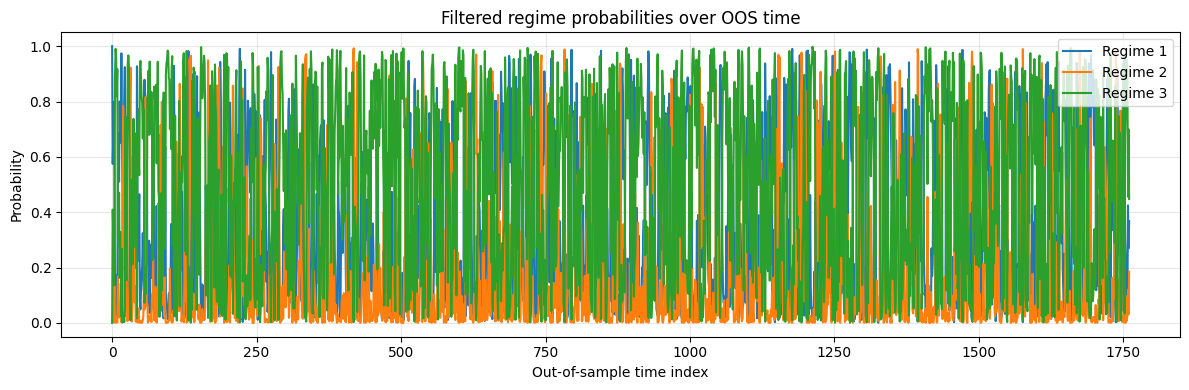

In [7]:
K = gamma.shape[1]

plt.figure(figsize=(12, 4))
for k in range(K):
    plt.plot(gamma[:, k], label=f"Regime {k+1}")
plt.title("Filtered regime probabilities over OOS time")
plt.xlabel("Out-of-sample time index")
plt.ylabel("Probability")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


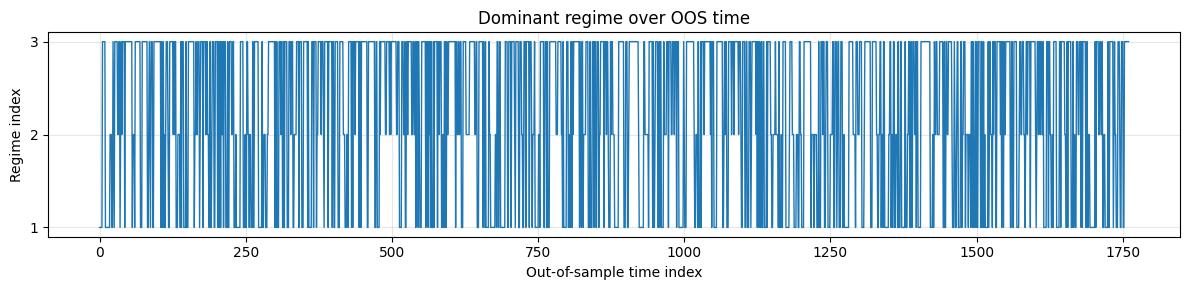

In [8]:
dom_regime = np.argmax(gamma, axis=1)

plt.figure(figsize=(12, 3))
plt.plot(dom_regime, lw=1)
plt.title("Dominant regime over OOS time")
plt.xlabel("Out-of-sample time index")
plt.ylabel("Regime index")
plt.yticks(range(K), [f"{k+1}" for k in range(K)])
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

,regime,share
0,Regime 1,0.312323
1,Regime 2,0.161840
2,Regime 3,0.525838


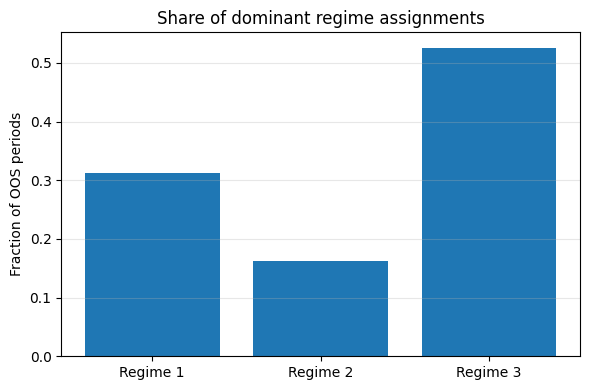

In [9]:
shares = np.bincount(dom_regime, minlength=K) / len(dom_regime)
share_df = pd.DataFrame({
    "regime": [f"Regime {k+1}" for k in range(K)],
    "share": shares
})
display(share_df)

plt.figure(figsize=(6,4))
plt.bar(share_df["regime"], share_df["share"])
plt.title("Share of dominant regime assignments")
plt.ylabel("Fraction of OOS periods")
plt.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

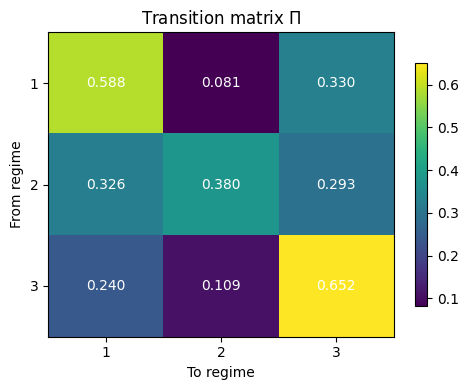

In [10]:
fig, ax = plt.subplots(figsize=(5,4))
im = ax.imshow(Pi, aspect="auto")
ax.set_title("Transition matrix $\\Pi$")
ax.set_xlabel("To regime")
ax.set_ylabel("From regime")
ax.set_xticks(range(K))
ax.set_yticks(range(K))
ax.set_xticklabels([f"{k+1}" for k in range(K)])
ax.set_yticklabels([f"{k+1}" for k in range(K)])

for i in range(K):
    for j in range(K):
        ax.text(j, i, f"{Pi[i,j]:.3f}", ha="center", va="center", color="white")

fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

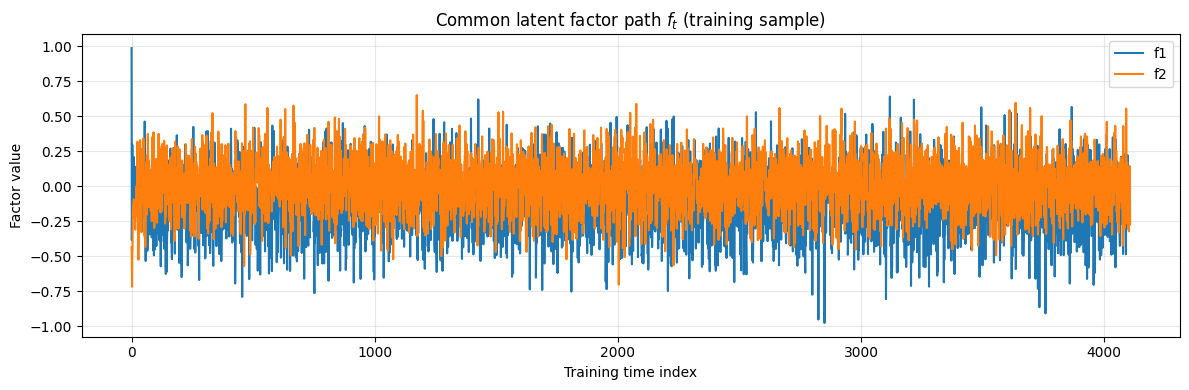

In [11]:
r = f_t.shape[1]

plt.figure(figsize=(12, 4))
for j in range(r):
    plt.plot(f_t[:, j], label=f"f{j+1}")
plt.title("Common latent factor path $f_t$ (training sample)")
plt.xlabel("Training time index")
plt.ylabel("Factor value")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

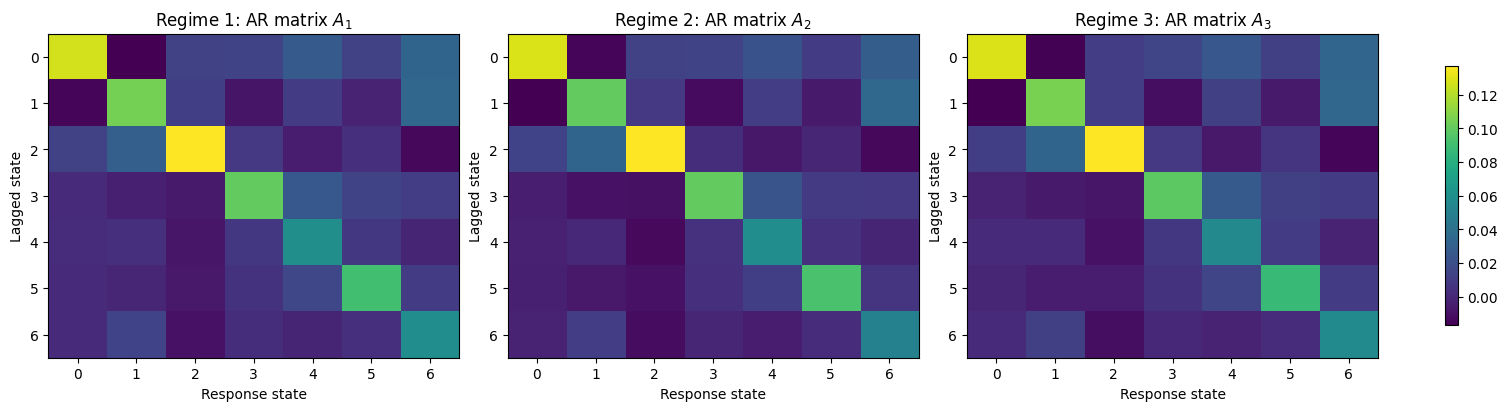

In [12]:
K, d, _ = A.shape

fig, axes = plt.subplots(1, K, figsize=(5*K, 4), constrained_layout=True)

if K == 1:
    axes = [axes]

for k in range(K):
    im = axes[k].imshow(A[k], aspect="auto")
    axes[k].set_title(f"Regime {k+1}: AR matrix $A_{k+1}$")
    axes[k].set_xlabel("Response state")
    axes[k].set_ylabel("Lagged state")
    axes[k].set_xticks(range(d))
    axes[k].set_yticks(range(d))

fig.colorbar(im, ax=axes, shrink=0.8)
plt.show()

In [13]:
rows = []
for k in range(K):
    Ak = A[k]
    diag_mean = np.mean(np.diag(Ak))
    offdiag = Ak - np.diag(np.diag(Ak))
    offdiag_mean = np.mean(np.abs(offdiag))
    rows.append({
        "regime": f"Regime {k+1}",
        "mean_diag_A": diag_mean,
        "mean_abs_offdiag_A": offdiag_mean
    })

A_summary = pd.DataFrame(rows)
display(A_summary)

,regime,mean_diag_A,mean_abs_offdiag_A
0,Regime 1,0.098568,0.008842
1,Regime 2,0.096236,0.008898
2,Regime 3,0.095600,0.009240


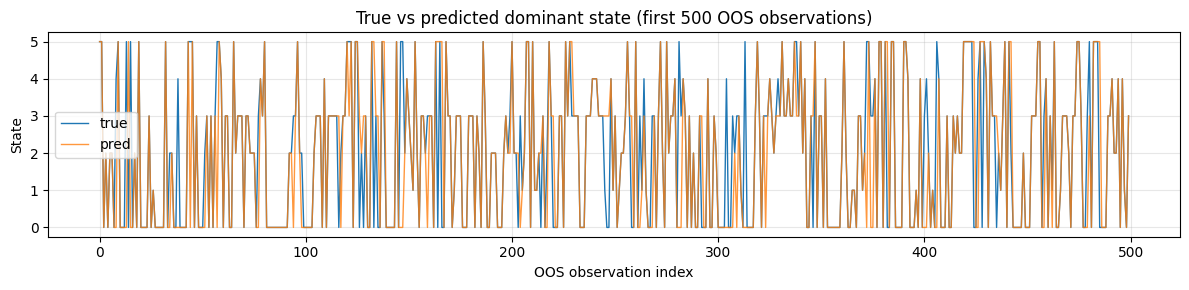

In [14]:
true_state = np.argmax(y_true, axis=1)
pred_state = np.argmax(y_pred, axis=1)

plt.figure(figsize=(12,3))
plt.plot(true_state[:500], label="true", lw=1)
plt.plot(pred_state[:500], label="pred", lw=1, alpha=0.8)
plt.title("True vs predicted dominant state (first 500 OOS observations)")
plt.xlabel("OOS observation index")
plt.ylabel("State")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()